<a href="https://colab.research.google.com/github/johnsteeleprogramming/techconsulting/blob/DS_Assignment3/Assignment_3_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WEEK 3 LINEAR REGRESSION

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## READ DATA FROM FILE 'raw_house_data_cleaned.csv'

In [167]:
X_read = pd.DataFrame(pd.read_csv('/content/raw_house_data_cleaned.csv'))

In [168]:
X_read.columns

Index(['MLS', 'sold_price', 'zipcode', 'longitude', 'latitude', 'lot_acres',
       'taxes', 'year_built', 'bedrooms', 'bathrooms', 'sqrt_ft', 'garage',
       'kitchen_features', 'fireplaces', 'floor_covering', 'HOA'],
      dtype='object')

### DROP UNNECESSARY COLUMNS

In [169]:
X_read.drop(['MLS','zipcode','longitude','latitude','taxes','year_built','bedrooms','bathrooms','kitchen_features','fireplaces','floor_covering','HOA'],axis=1,inplace=True)

In [170]:
X_read

,sold_price,lot_acres,sqrt_ft,garage
0,5300000.0,2154.00,10500.000000,0.0
1,4200000.0,1707.00,7300.000000,0.0
2,4200000.0,1707.00,3716.366828,0.0
3,4500000.0,636.67,9019.000000,4.0
4,3411450.0,3.21,6396.000000,3.0
...,...,...,...,...
4995,495000.0,4.98,3601.000000,3.0
4996,550000.0,1.42,2318.000000,3.0
4997,475000.0,12.06,1772.000000,0.0
4998,550000.0,1.01,3724.000000,3.0


### CREATE TRAINING SETS

In [171]:
X = pd.DataFrame(X_read)

In [172]:
y=X.loc[:,['sold_price']]

In [173]:
X=X.loc[:,['lot_acres','sqrt_ft','garage']]

## FUNCTIONS

### FUNCTIONS TO CHECK FOR ACCURACY

In [174]:
def MAE(Y, Y_hat):
  return np.sum(np.abs(Y-Y_hat))/len(Y)

def R2(Y, Y_hat):
  N=len(Y)
  return 1-(np.sum((Y-Y_hat)**2)/np.sum((Y_hat-np.mean(Y))**2))

def OLS(Y, Y_hat, N):
  #N=len(Y)
  return ((1/(2*N))*np.sum((Y-Y_hat)**2))

### MULTI-VARIANT LINEAR REGRESSION MODEL

In [175]:
class MVLinearRegression():

  def fit(self, X, y, eta=5e-9, epochs=3e3, show_curve=False):
    epochs = int(epochs)
    N, D = X.shape
    Y=y[:,0]
    self.W = np.random.randn(D)
    self.J = np.zeros(epochs)

    for epoch in range(epochs):
      Y_hat = self.predict(X)
      self.J[epoch] = OLS(Y, Y_hat, N)
      self.W -= eta*(1/N)*(X.T@(Y_hat-Y))

    if show_curve:
      plt.figure()
      plt.plot(self.J)
      plt.xlabel("epochs")
      plt.ylabel("$ \mathcal{J}$")
      plt.title("Training Curve")

  def predict(self, X):
    return X@self.W

## INITIALIZE AND TRAIN MODEL

In [176]:
my_reg = MVLinearRegression()

In [177]:
my_reg.fit(X,y.to_numpy())

In [178]:
def predict_house(X_test,model):
  y_out = model.predict(X_test)
  return y_out

### TEST MODEL WITH SAMPLES

In [179]:
# lot_acres, sqrt_ft, garage
X_test_0 = np.array([2154.00,10500.000000,0.0])
y_test_0 = np.array([5300_000.0])
X_test_1 = np.array([1.66, 5981, 6])
y_test_1 = np.array([900_000.0])

In [180]:
y_test_result_0 = predict_house(X_test_0, my_reg)
print(y_test_result_0/y_test_0[0])

0.4289956197819358


In [181]:
y_test_result_1 = predict_house(X_test_1, my_reg)
print(y_test_result_1/y_test_1[0])

1.352493777717369


In [182]:
y_hat = predict_house(X,my_reg)

### ACCURACY OF MODEL

In [183]:
accuracy = y_hat.mean()/y.mean()
print('--- ACCURACY OF MODEL BEFORE SEPARATING DATA BY GARAGE SIZE ---')
print('Accuracy: ' + str(accuracy.iloc[0]))

--- ACCURACY OF MODEL BEFORE SEPARATING DATA BY GARAGE SIZE ---
Accuracy: 0.9767059980532836


## RECOMBINE DATASET

In [184]:
X['sold_price'] = y['sold_price']

In [185]:
X['predict_sold_price'] = y_hat[0]

## SPLIT DATASET BASED ON SIZE OF GARAGE

In [186]:
X_0 = X.where(X['garage'] == 0)
X_0.dropna(inplace=True)
X_1 = X.where(X['garage'] == 1)
X_1.dropna(inplace=True)
X_2 = X.where(X['garage'] == 2)
X_2.dropna(inplace=True)
X_3 = X.where(X['garage'] == 3)
X_3.dropna(inplace=True)
X_4_more = X.where(X['garage'] >= 4)
X_4_more.dropna(inplace=True)

In [187]:
y_0 = X_0.loc[:,['sold_price']]
X_0 = X_0.loc[:,['lot_acres','sqrt_ft','garage']]
y_1 = X_1.loc[:,['sold_price']]
X_1 = X_1.loc[:,['lot_acres','sqrt_ft','garage']]
y_2 = X_2.loc[:,['sold_price']]
X_2 = X_2.loc[:,['lot_acres','sqrt_ft','garage']]
y_3 = X_3.loc[:,['sold_price']]
X_3 = X_3.loc[:,['lot_acres','sqrt_ft','garage']]
y_4_more = X_4_more.loc[:,['sold_price']]
X_4_more = X_4_more.loc[:,['lot_acres','sqrt_ft','garage']]

## INITIALIZE AND TRAIN MODELS WITH DATASET SEPARATED BY GARAGE SIZE

In [188]:
my_reg_0 = MVLinearRegression()
my_reg_1 = MVLinearRegression()
my_reg_2 = MVLinearRegression()
my_reg_3 = MVLinearRegression()
my_reg_4_more = MVLinearRegression()

In [189]:
my_reg_0.fit(X_0,y_0.to_numpy())
my_reg_1.fit(X_1,y_1.to_numpy())
my_reg_2.fit(X_2,y_2.to_numpy())
my_reg_3.fit(X_3,y_3.to_numpy())
my_reg_4_more.fit(X_4_more,y_4_more.to_numpy())

In [190]:
y_hat_0 = predict_house(X_0,my_reg_0)
y_hat_1 = predict_house(X_1,my_reg_1)
y_hat_2 = predict_house(X_2,my_reg_2)
y_hat_3 = predict_house(X_3,my_reg_3)
y_hat_4_more = predict_house(X_4_more,my_reg_4_more)

### ACCURACIES OF EACH MODEL

In [191]:
y_hat_0_mean = y_hat_0.mean()/y_0['sold_price'].mean()
y_hat_1_mean = y_hat_1.mean()/y_1['sold_price'].mean()
y_hat_2_mean = y_hat_2.mean()/y_2['sold_price'].mean()
y_hat_3_mean = y_hat_3.mean()/y_3['sold_price'].mean()
y_hat_4_more_mean = y_hat_4_more.mean()/y_4_more['sold_price'].mean()
print('--- ACCURACIES OF MODELS SEPARATED BY GARAGE SIZE ---')
print('Garage size 0: ' + str(y_hat_0_mean))
print('Garage size 1: ' + str(y_hat_1_mean))
print('Garage size 2: ' + str(y_hat_2_mean))
print('Garage size 3: ' + str(y_hat_3_mean))
print('Garage size 4 or more: ' + str(y_hat_4_more_mean))

--- ACCURACIES OF MODELS SEPARATED BY GARAGE SIZE ---
Garage size 0: 0.7766368826932637
Garage size 1: 0.8817185678297759
Garage size 2: 0.9592557396895778
Garage size 3: 1.0000892057331725
Garage size 4 or more: 1.0004267743176938


### SAMPLING MODELS

In [192]:
print('--- SAMPLE TEST ---')
print('--- To use sample test, need array with [lot_acres, sqrt_ft, garage] ---')
print("--- For 0 garage, use 'my_reg_0' ---")
print("--- For 1 garage, use 'my_reg_1' ---")
print("--- For 2 garage, use 'my_reg_2' ---")
print("--- For 3 garage, use 'my_reg_3' ---")
print("--- For 4 or more garages, use 'my_reg_4_more' ---")
# [lot_acres, sqrt_ft, garage]
X_test_0 = np.array([1.66, 5981, 6])
y_test_0 = np.array([900_000.0])
X_test_1 = np.array([1.28, 5290, 4])
y_test_1 = np.array([860_000.0])
X_test_2 = np.array([0.88, 3942, 3])
y_test_2 = np.array([880_000.0])
X_test_3 = np.array([0.18, 1340, 0])
y_test_3 = np.array([172_000.0])
X_test_4 = np.array([1, 1955, 2])
y_test_4 = np.array([351_200.0])
X_test_5 = np.array([0.77, 1779, 4])
y_test_5 = np.array([332900.0])

--- SAMPLE TEST ---
--- To use sample test, need array with [lot_acres, sqrt_ft, garage] ---
--- For 0 garage, use 'my_reg_0' ---
--- For 1 garage, use 'my_reg_1' ---
--- For 2 garage, use 'my_reg_2' ---
--- For 3 garage, use 'my_reg_3' ---
--- For 4 or more garages, use 'my_reg_4_more' ---


In [193]:
y_test_result_0 = predict_house(X_test_0, my_reg_4_more)
print(y_test_result_0)
print(y_test_result_0/y_test_0[0])
y_test_result_1 = predict_house(X_test_1, my_reg_4_more)
print(y_test_result_1)
print(y_test_result_1/y_test_1[0])
y_test_result_2 = predict_house(X_test_2, my_reg_3)
print(y_test_result_2)
print(y_test_result_2/y_test_2[0])
y_test_result_3 = predict_house(X_test_3, my_reg_0)
print(y_test_result_3)
print(y_test_result_3/y_test_3[0])
y_test_result_4 = predict_house(X_test_4, my_reg_2)
print(y_test_result_4)
print(y_test_result_4/y_test_4[0])
y_test_result_5 = predict_house(X_test_5, my_reg_4_more)
print(y_test_result_5)
print(y_test_result_5/y_test_5[0])

1191858.417322618
1.3242871303584645
1054149.0465895634
1.2257547053367015
832190.5175454827
0.9456710426653213
202113.06631517355
1.1750759669486834
389667.7797645316
1.109532402518598
354524.41889261216
1.0649577016900336


## BAR GRAPH SHOWING ACCURACIES OF GARAGE SIZE MODELS

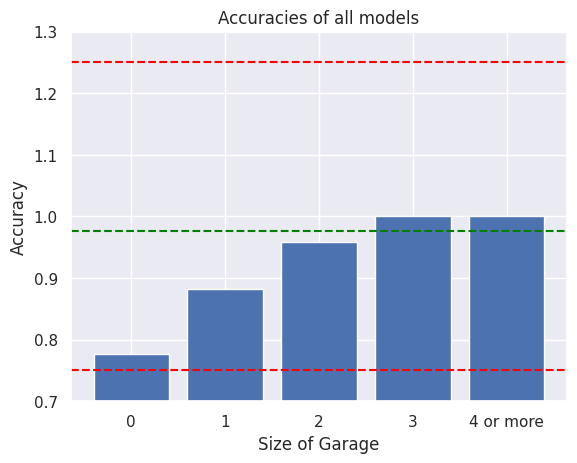

In [194]:
x_axis = ['0', '1', '2', '3', '4 or more']
y_axis = [y_hat_0_mean,y_hat_1_mean,y_hat_2_mean,y_hat_3_mean,y_hat_4_more_mean]
plt.bar(x_axis,y_axis)
plt.axhline(y=accuracy.iloc[0],color='green',linestyle='--')
plt.axhline(y=0.75,color='red',linestyle='--')
plt.axhline(y=1.25,color='red',linestyle='--')
plt.ylim(0.7, 1.3)
plt.xlabel('Size of Garage')
plt.ylabel('Accuracy')
plt.title('Accuracies of all models')
plt.show()